# Stage 2 - Classical Supervised Learning

Import the required libraries

In [47]:
import pandas as pd
import ast
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score
)
from sklearn.metrics import ConfusionMatrixDisplay

First will be a linear regression model to predict revenue based on relevant features such as budget, runtime, genre, and cast size.

In [48]:
# Retrieve data from Stage 1
df = pd.read_csv('data/movies_clean.csv')
df = df.drop(columns=df.columns[0])

# From Stage 1: Clean the csv into python intrepretable data
columns_to_parse = []
for col in df.select_dtypes(include='str').columns:
    if df[col].iloc[0].strip().startswith(('[', '{')):
        columns_to_parse.append(col)

def parse_names(column):
    try:
        return ast.literal_eval(column)
    except (ValueError, SyntaxError):
        return []

for column in columns_to_parse:
    df[column] = df[column].apply(parse_names)

# Fix the genres column to work with regression
mlb = MultiLabelBinarizer()
tag_matrix = mlb.fit_transform(df['genres'])
mlb.classes_


array(['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
       'Documentary', 'Drama', 'Family', 'Fantasy', 'Foreign', 'History',
       'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
       'TV Movie', 'Thriller', 'War', 'Western'], dtype=object)

In [49]:
# Convert grid to dataframe
tag_df = pd.DataFrame(tag_matrix, columns=mlb.classes_, index=df.index)

# Concat dataframes
df = pd.concat([df, tag_df], axis=1)

df.head(5)

,title,cast,crew,budget,genres,homepage,id,keywords,original_language,original_title,...,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
0,Avatar,"[Sam Worthington, Zoe Saldana, Sigourney Weave...","[Stephen E. Rivkin, Rick Carter, Christopher B...",237000000,"[Action, Adventure, Fantasy, Science Fiction]",http://www.avatarmovie.com/,19995,"[culture clash, future, space war, space colon...",en,Avatar,...,0,0,0,0,0,1,0,0,0,0
1,Pirates of the Caribbean: At World's End,"[Johnny Depp, Orlando Bloom, Keira Knightley, ...","[Dariusz Wolski, Gore Verbinski, Jerry Bruckhe...",300000000,"[Adventure, Fantasy, Action]",http://disney.go.com/disneypictures/pirates/,285,"[ocean, drug abuse, exotic island, east india ...",en,Pirates of the Caribbean: At World's End,...,0,0,0,0,0,0,0,0,0,0
2,Spectre,"[Daniel Craig, Christoph Waltz, Léa Seydoux, R...","[Thomas Newman, Sam Mendes, Anna Pinnock, John...",245000000,"[Action, Adventure, Crime]",http://www.sonypictures.com/movies/spectre/,206647,"[spy, based on novel, secret agent, sequel, mi...",en,Spectre,...,0,0,0,0,0,0,0,0,0,0
3,The Dark Knight Rises,"[Christian Bale, Michael Caine, Gary Oldman, A...","[Hans Zimmer, Charles Roven, Christopher Nolan...",250000000,"[Action, Crime, Drama, Thriller]",http://www.thedarkknightrises.com/,49026,"[dc comics, crime fighter, terrorist, secret i...",en,The Dark Knight Rises,...,0,0,0,0,0,0,0,1,0,0
4,John Carter,"[Taylor Kitsch, Lynn Collins, Samantha Morton,...","[Andrew Stanton, Andrew Stanton, John Lasseter...",260000000,"[Action, Adventure, Science Fiction]",http://movies.disney.com/john-carter,49529,"[based on novel, mars, medallion, space travel...",en,John Carter,...,0,0,0,0,0,1,0,0,0,0


In [50]:
# Set model
model = LinearRegression()


# Set features and split dataset
X = df[['budget','runtime','cast_size'] + list(mlb.classes_)]
y = df['revenue']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train and fit model
model.fit(X_train, y_train)
predictions = model.predict(X_test)

# Analyze results
lr_mse = mean_squared_error(y_test, predictions)
lr_r2 = r2_score(y_test, predictions)

print(f'MSE: {lr_mse:.2e}\tR2: {lr_r2}')


MSE: 1.03e+16	R2: 0.6111267103834686


Now we will switch the model to Random Forest Regressor

In [51]:
# Set model
model = RandomForestRegressor()


# Set features and split dataset
X = df[['budget','runtime','cast_size'] + list(mlb.classes_)]
y = df['revenue']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train and fit model
model.fit(X_train, y_train)
predictions = model.predict(X_test)

# Analyze results
rfr_mse = mean_squared_error(y_test, predictions)
rfr_r2 = r2_score(y_test, predictions)

print(f'MSE: {rfr_mse:.2e}\tR2: {rfr_r2}')


MSE: 8.92e+15	R2: 0.6646786178852442


And once more to Gradient Boosting Regressor

In [52]:
# Set model
model = GradientBoostingRegressor()


# Set features and split dataset
X = df[['budget','runtime','cast_size'] + list(mlb.classes_)]
y = df['revenue']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train and fit model
model.fit(X_train, y_train)
predictions = model.predict(X_test)

# Analyze results
gbr_mse = mean_squared_error(y_test, predictions)
gbr_r2 = r2_score(y_test, predictions)

print(f'MSE: {gbr_mse:.2e}\tR2: {gbr_r2}')


MSE: 8.68e+15	R2: 0.6736293947525378


Comparing the scores, the lowest MSE and highest R2 is the Gradient Boosting Regressor. The highest MSE and lowest R2 is Linear Regression. The Gradient Boosting Regressor model works best for this data.

<Figure size 640x480 with 0 Axes>

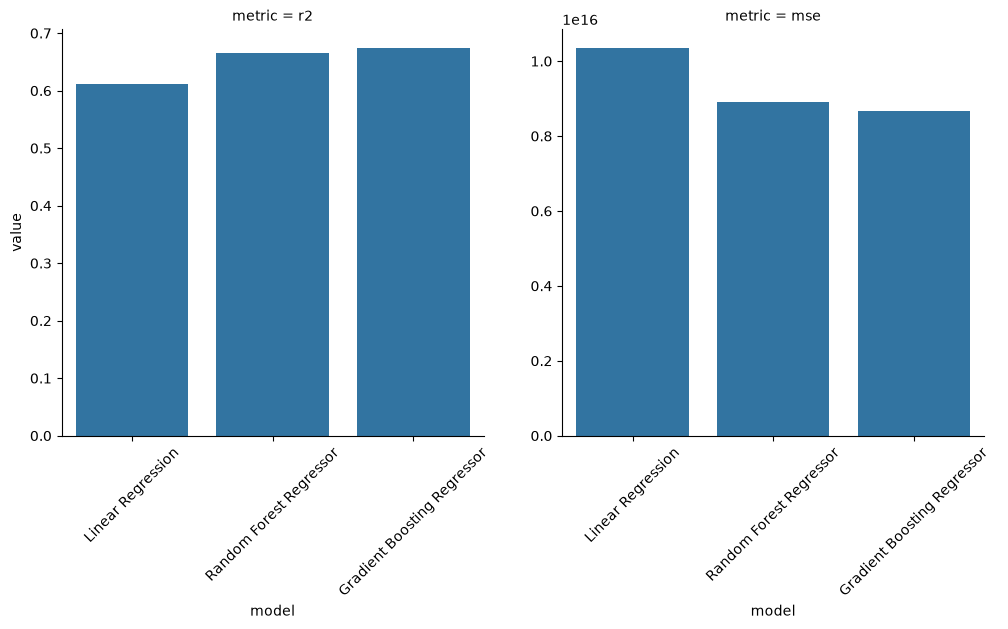

In [53]:
results = pd.DataFrame({
    'model': ['Linear Regression','Linear Regression','Random Forest Regressor','Random Forest Regressor','Gradient Boosting Regressor','Gradient Boosting Regressor'],
    'metric': ['r2', 'mse', 'r2', 'mse', 'r2', 'mse'],
    'value': [lr_r2, lr_mse, rfr_r2, rfr_mse, gbr_r2, gbr_mse]
})

plt.tight_layout()
g = sns.catplot(data=results, x='model', y='value', col='metric', kind='bar', sharey=False)

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.savefig('images/regression_model_comparison.png', bbox_inches='tight')

Now we will switch to classification in order to determine if the movie generated profit.

Accuracy: 0.6864583333333333
Precision: 0.7112403100775194
Recall: 0.7071290944123314
F1: 0.7091787439613526
ROC AUC: 0.7486969097208569


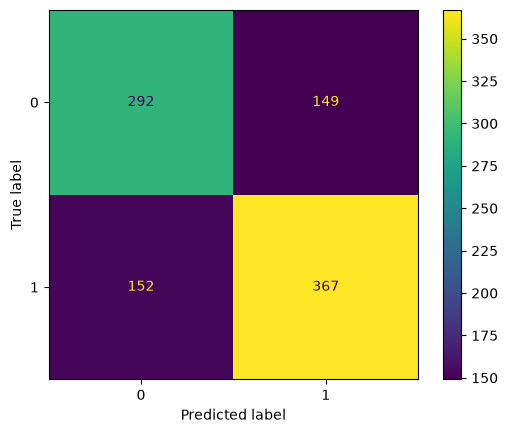

In [54]:
# Add a new column to the dataset for binary made_profit
df['made_profit'] = (df['profit'] > 0).astype(int)

# Set features and split dataset
y = df['made_profit']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Set model
model = LogisticRegression()

# Train and fit model
model.fit(X_train, y_train)
predictions = model.predict(X_test)

# Analyze results
log_acc = accuracy_score(y_test, predictions)
log_prec = precision_score(y_test, predictions)
log_recall = recall_score(y_test, predictions)
log_f1 = f1_score(y_test, predictions)
ConfusionMatrixDisplay.from_predictions(y_test, predictions)
log_probabilities = model.predict_proba(X_test)[:, 1]
log_roc= roc_auc_score(y_test, log_probabilities)

print(f'Accuracy: {log_acc}\nPrecision: {log_prec}\nRecall: {log_recall}\nF1: {log_f1}\nROC AUC: {log_roc}')

Accuracy: 0.7177083333333333
Precision: 0.7108843537414966
Recall: 0.8053949903660886
F1: 0.7551942186088527
ROC AUC: 0.7843533045845185


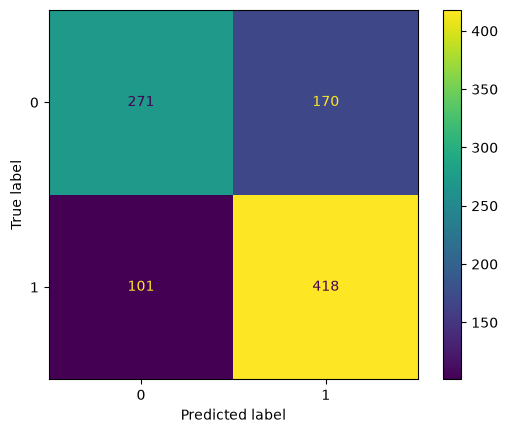

In [55]:
# Set model
model = RandomForestClassifier()

# Train and fit model
model.fit(X_train, y_train)
predictions = model.predict(X_test)

# Analyze results
rfc_acc = accuracy_score(y_test, predictions)
rfc_prec = precision_score(y_test, predictions)
rfc_recall = recall_score(y_test, predictions)
rfc_f1 = f1_score(y_test, predictions)
ConfusionMatrixDisplay.from_predictions(y_test, predictions)
rfc_probabilities = model.predict_proba(X_test)[:, 1]
rfc_roc= roc_auc_score(y_test, rfc_probabilities)

print(f'Accuracy: {rfc_acc}\nPrecision: {rfc_prec}\nRecall: {rfc_recall}\nF1: {rfc_f1}\nROC AUC: {rfc_roc}')

Accuracy: 0.64375
Precision: 0.672514619883041
Recall: 0.6647398843930635
F1: 0.6686046511627907
ROC AUC: 0.6418937517203414


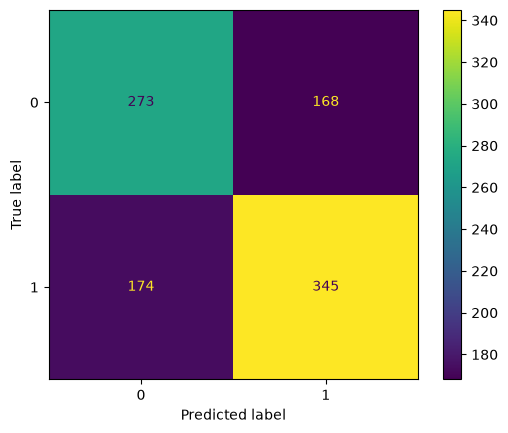

In [56]:
# Set model
model = DecisionTreeClassifier()

# Train and fit model
model.fit(X_train, y_train)
predictions = model.predict(X_test)

# Analyze results
dtc_acc = accuracy_score(y_test, predictions)
dtc_prec = precision_score(y_test, predictions)
dtc_recall = recall_score(y_test, predictions)
dtc_f1 = f1_score(y_test, predictions)
ConfusionMatrixDisplay.from_predictions(y_test, predictions)
dtc_probabilities = model.predict_proba(X_test)[:, 1]
dtc_roc= roc_auc_score(y_test, dtc_probabilities)

print(f'Accuracy: {dtc_acc}\nPrecision: {dtc_prec}\nRecall: {dtc_recall}\nF1: {dtc_f1}\nROC AUC: {dtc_roc}')

<Figure size 640x480 with 0 Axes>

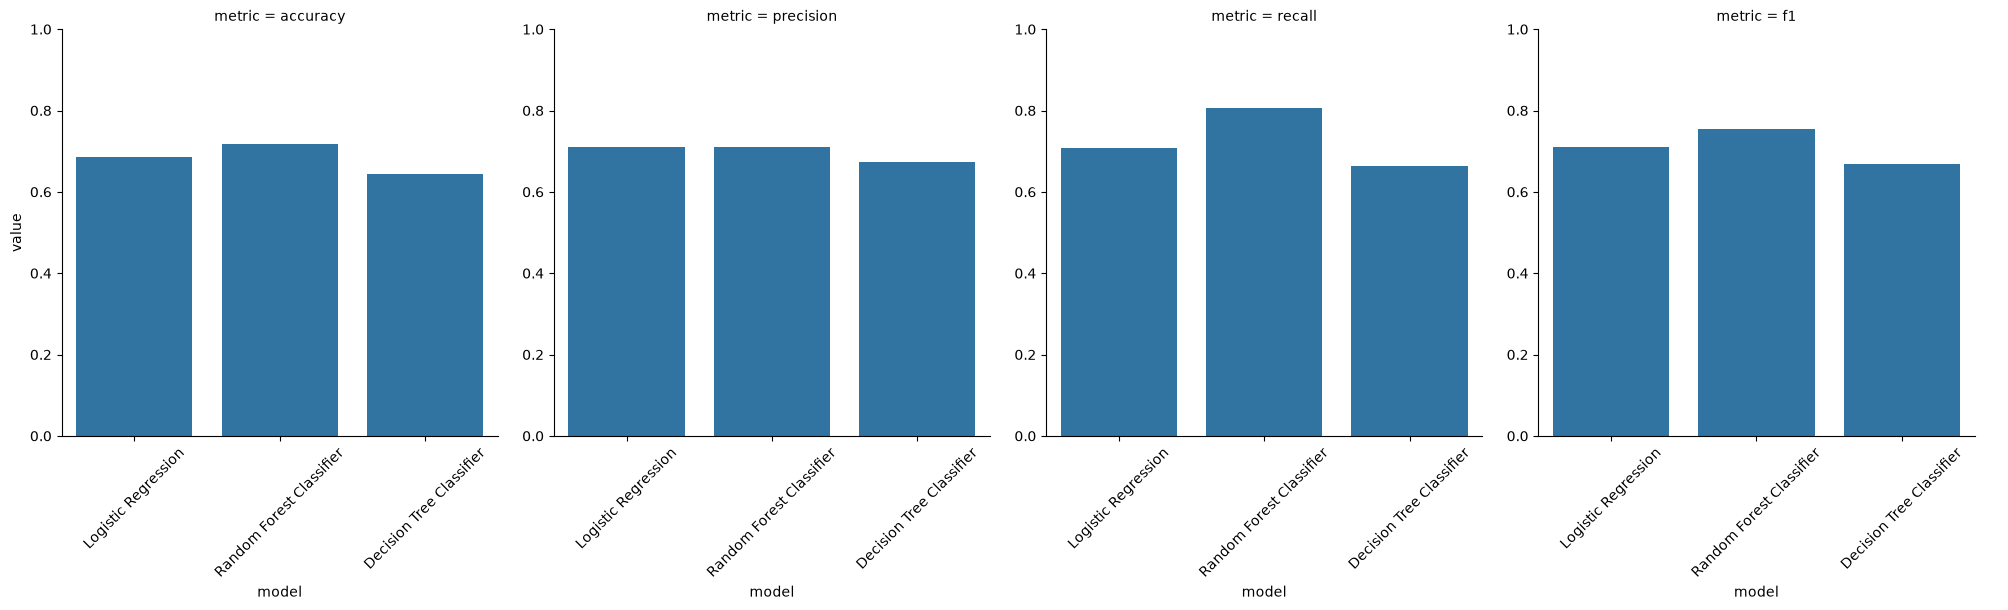

In [57]:
results_classification = pd.DataFrame({
    'model': ['Logistic Regression','Logistic Regression','Logistic Regression','Logistic Regression','Random Forest Classifier','Random Forest Classifier','Random Forest Classifier','Random Forest Classifier','Decision Tree Classifier','Decision Tree Classifier','Decision Tree Classifier','Decision Tree Classifier'],
    'metric': ['accuracy', 'precision', 'recall', 'f1', 'accuracy', 'precision', 'recall', 'f1', 'accuracy', 'precision', 'recall', 'f1'],
    'value': [log_acc, log_prec, log_recall, log_f1, rfc_acc, rfc_prec, rfc_recall, rfc_f1, dtc_acc, dtc_prec, dtc_recall, dtc_f1]
})

plt.tight_layout()
g = sns.catplot(data=results_classification, x='model', y='value', col='metric', kind='bar', sharey=False)

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0,1)

plt.savefig('images/classification_model_comparison.png', bbox_inches='tight')

Random Forest Classifier seems to have the best scores in all categories. Lets go further with GridSearchCV

In [58]:
# Set model
model = RandomForestClassifier(random_state=42)

# Set parameters
param_grid_1 = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10]
}

grid_search_1 = GridSearchCV(model, param_grid_1, cv=5, scoring='accuracy')

grid_search_1.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of inform

N_estimators = 50 and max_depth = 5. Lets do a finer search

In [59]:
# Set parameters
param_grid_2 = {
    'n_estimators': [40, 50, 60],
    'max_depth': [4, 5, 6]
}

grid_search_2 = GridSearchCV(model, param_grid_2, cv=5, scoring='accuracy')

grid_search_2.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [4, 5, ...], 'n_estimators': [40, 50, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of informa

Still left with 50 and 5, therefore we can conclude these are the best parameters. Lets try running it

Accuracy: 0.7291666666666666
Precision: 0.7092084006462036
Recall: 0.8458574181117534
F1: 0.7715289982425307
ROC AUC: 0.7920014505481061


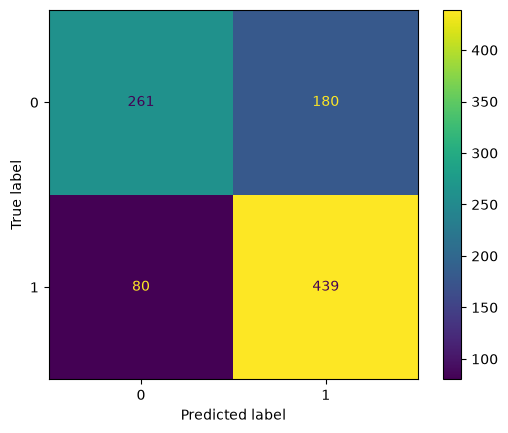

In [60]:
grid_predictions = grid_search_2.predict(X_test)

grid_acc = accuracy_score(y_test, grid_predictions)
grid_prec = precision_score(y_test, grid_predictions)
grid_recall = recall_score(y_test, grid_predictions)
grid_f1 = f1_score(y_test, grid_predictions)
ConfusionMatrixDisplay.from_predictions(y_test, grid_predictions)
grid_probabilities = grid_search_2.predict_proba(X_test)[:, 1]
grid_roc= roc_auc_score(y_test, grid_probabilities)

print(f'Accuracy: {grid_acc}\nPrecision: {grid_prec}\nRecall: {grid_recall}\nF1: {grid_f1}\nROC AUC: {grid_roc}')

Comparing the original results to the grid search results

<Figure size 640x480 with 0 Axes>

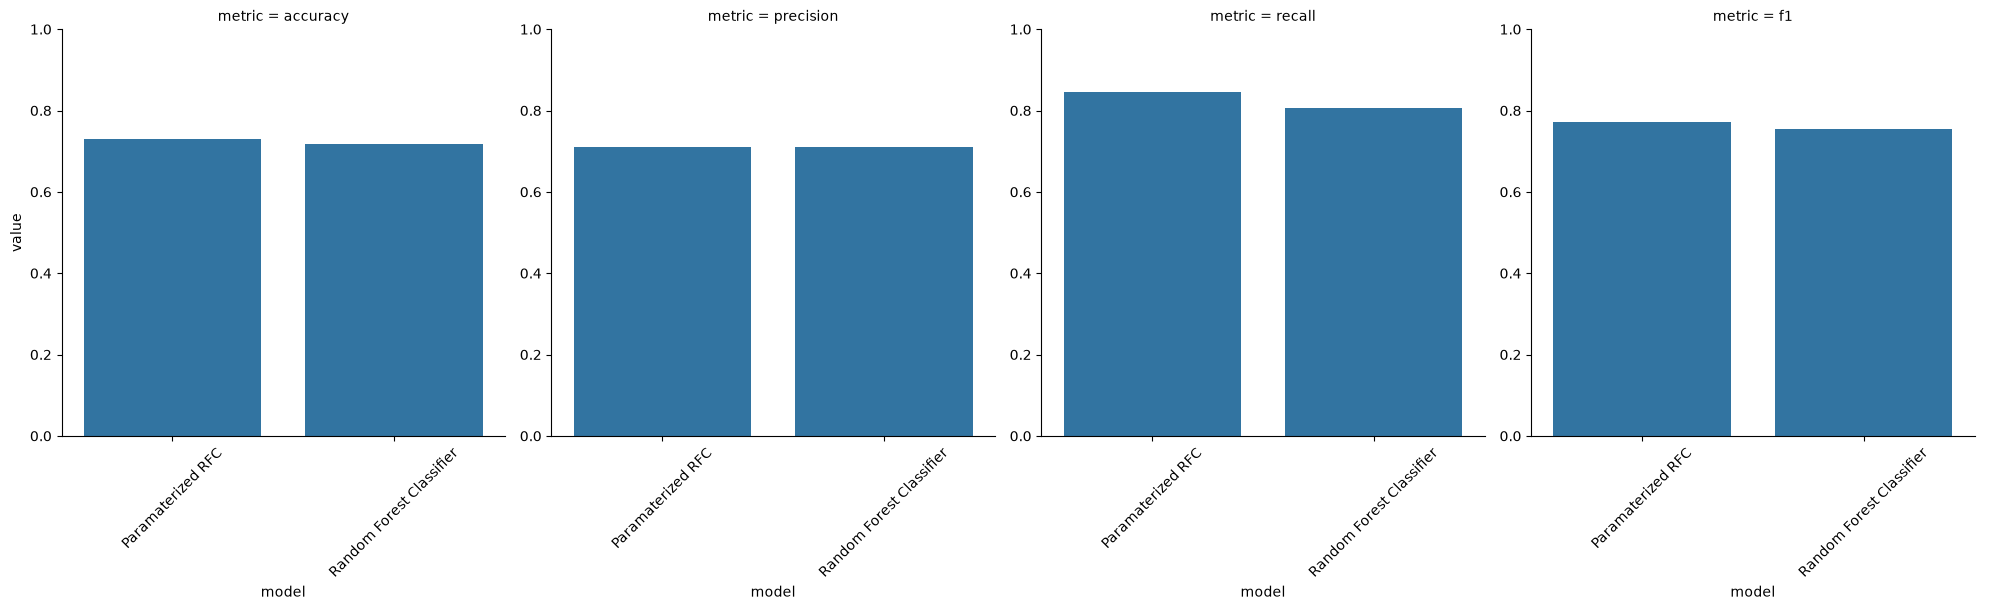

In [61]:
results_classification = pd.DataFrame({
    'model': ['Paramaterized RFC','Paramaterized RFC','Paramaterized RFC','Paramaterized RFC','Random Forest Classifier','Random Forest Classifier','Random Forest Classifier','Random Forest Classifier'],
    'metric': ['accuracy', 'precision', 'recall', 'f1', 'accuracy', 'precision', 'recall', 'f1'],
    'value': [grid_acc, grid_prec, grid_recall, grid_f1, rfc_acc, rfc_prec, rfc_recall, rfc_f1]
})

plt.tight_layout()
g = sns.catplot(data=results_classification, x='model', y='value', col='metric', kind='bar', sharey=False)

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0,1)

plt.savefig('images/grid_search.png', bbox_inches='tight')

We can see slight increases in accuracy, recall, and f1 scores. Adjusting the parameters helped make the model better. Here Random Forest Classifier was used as it showed the best results without adjusting parameters and then I further adjusted the parameters to increase accuracy, recall, and f1 even further. Another model may have worked similarly or even better, but Random Forest Classifier handles pretty well in this scenario.

In [62]:
df.to_csv('data/movies_encoded_genres.csv')